# Plot polymer dynamics and calculate statistics

In [1]:
#Include necessary librarires
using Plots
using FFTW
using LinearAlgebra

In [2]:
#Define functions
#Function for giration vector
#Returns: giration vector
function calcgir(datasr_::Array{Float64,3}, N_::Int32, start_::Int64, end_::Int64, skip_::Int64)
    times::Int64 = length(@view(datasr_[:,1,1]));
    corrr::Vector{Float64} = zeros(N_);
    r1fft::Vector{ComplexF64} = zeros(ComplexF64, N_÷2+1);
    r2fft::Vector{ComplexF64} = zeros(ComplexF64, N_÷2+1);
    r3fft::Vector{ComplexF64} = zeros(ComplexF64, N_÷2+1);

    for i in start_:skip_:end_
            r1fft = fft(@view(datasr_[i,:,1]));
            r2fft = fft(@view(datasr_[i,:,2]));
            r3fft = fft(@view(datasr_[i,:,3]));
            corrr .+= -2*real.(ifft(abs.(r1fft).^2+abs.(r2fft).^2+abs.(r3fft).^2)).+2 .*sum(abs.(r1fft).^2+abs.(r2fft).^2+abs.(r3fft).^2)/N_;
    end
    return corrr/N_/((end_-start_)/skip_);
end

#Function to plot dynamics of average profile of epigenetic field
function plot_totprof(profile::Matrix{Float64}, tot_time::Int64)
    N::Int64 = length(@view(profile[1,:]));
    time_length::Int64 = length(@view(profile[:,1]));
    true_time::Int64 = tot_time;
    if tot_time > time_length
        true_time = time_length;
    end
    tot_sum::Vector{Float64} = zeros(true_time);
    for i in eachindex(tot_sum)
        tot_sum[i] = sum(@view(profile[i,:]))/N;
    end
    plot(tot_sum)
    xlabel!("Time")
    ylabel!("Total concentration")
end

#Function to calculate correlation functions and averages
#Returns: correlation func., conn. correlation func., average over time
function calccorrh(datash_::Matrix{Float64}, Nt_::Int32, start_::Int64, skip_::Int64)
        
    N = length(@view(datash_[1,:]));
    times = length(@view(datash_[:,1]))-start_;
    corrh::Vector{Float64} = zeros(N);
    avgh1::Float64 = 0.0;
    avgh::Vector{Float64} = zeros(Float64, N);
    avgt::Vector{Float64} = zeros(times);
    hk::Vector{ComplexF64} = zeros(ComplexF64, N);
    hks::Vector{Float64} = zeros(Float64, N);
    hkt::Vector{Float64} = zeros(Float64, N);
    tot = (length(@view(datash_[:,1]))-start_)/(skip_);
    
    for i::Int64 in 1:times
        avgt[i] = sum(@view(datash_[i,:]))/N;
    end
    

    for i::Int64 in start_:skip_:(times+start_)
        hk .= fft(@view(datash_[i,:]));
        hks .+= abs.(hk).^2;
        corrh .+= real(ifft(abs.(hk).^2));
        if i == 1000
            hkt .= real(ifft(abs.(hk).^2));
        end
        avgh .+= datash_[i];
    end
    
    corrh .= corrh./((tot)*(N));
    print(corrh,"\n")
    hks .= hks./tot;
    hks[1] = 0;
    avgh .= avgh./(tot);
    avgh1 = sum(avgh)./length(avgh);
    return corrh, real(ifft(abs.(hks).^2)), avgt, avgh;

end

#Function for contact probability
#Returns: contact probability as a function of sequence distance
function pofs(datasr_::Array{Float64,3}, N_::Int32, radius_::Float64, start_::Int64, skip_::Int64)
    
    times::Int64 = length(@view(datasr_[:,1,1]));
    ps::Vector{Float64} = zeros(N_);
    for t in start_:skip_:times
        for i in 1:N_÷2
            for j in (i+1):(N_÷2+i-1)
                if mynorm(@view(datasr_[t,i,:])-@view(datasr_[t,j,:]))<radius_
                    ps[Int(abs(i-j))] += 1
                end
            end
        end
    end
    ps = ps/sum(ps);
    #ps = ps/length(start_:skip_:times);
    return ps
end

#Function that gets the center of mass of the polymer at a certain frame
#Returns center of mass coordinates
function get_com(frame_::Int32, datasr_::Array{Float64,3})
    return sum(datasr_[frame_,:,1])/N, sum(datasr_[frame_,:,2])/N, sum(datasr_[frame_,:,3])/N
end

#Personal vector norm function
function mynorm(v::Vector{Float64})
    return sqrt(dot(v,v));
end


mynorm (generic function with 1 method)

In [46]:
#Load data
N::Int32 = 2^10;
Nt::Int32 = 800;
ds::Float64 = 0.1;
array_save = Array{Float32}(undef, Nt*N*4);
#Read binary file containing the flattened particles positions vector
read!("/data/others/ciarchi/PolymerDyn/particles.bin",array_save);
data_r = zeros(Nt,N,3);
data_m = zeros(Nt,N);

#Unflatted vector
for t in 0:(Nt-1)
    for p in 0:(N-1)
        data_r[t+1,p+1,1] = array_save[t*(N*4)+p*4+1];
        data_r[t+1,p+1,2] = array_save[t*(N*4)+p*4+2];
        data_r[t+1,p+1,3] = array_save[t*(N*4)+p*4+3];
        data_m[t+1,p+1] = array_save[t*(N*4)+p*4+4];
    end
end

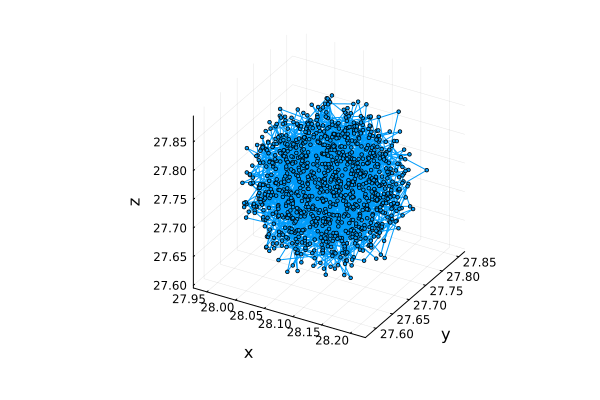

In [47]:
#Plot polymer dynamics

#Select frame
framec::Int32 = 800;

#Get center of mass at certain frame
com_frame_x, com_frame_y, com_frame_z  = get_com(framec,data_r);
#Get radius
rad_framec = 0.05;

# trace1 = scatter3d(;x=data_r[framec,1:(N),:][:,1],y=data_r[framec,1:(N),:][:,2],z=data_r[framec,1:(N),:][:,3]);
# plot(trace1)
Plots.plot(data_r[framec,1:(N),:][:,1],data_r[framec,1:(N),:][:,2],data_r[framec,1:(N),:][:,3], xlimits=(com_frame_x-3*rad_framec,com_frame_x+3*rad_framec),ylimits=(com_frame_y-3*rad_framec,com_frame_y+3*rad_framec),zlimits=(com_frame_z-3*rad_framec,com_frame_z+3*rad_framec), marker=:circle,markersize=2, legend=false)
xlabel!("x")
ylabel!("y")
zlabel!("z")

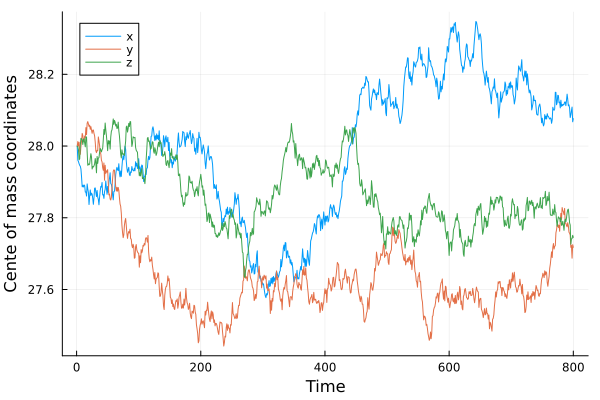

In [48]:
#Plot COM dynamics
coms = zeros(Nt,3);
for frame::Int32 in 1:Nt
    coms[frame, 1], coms[frame, 2], coms[frame, 3] = get_com(frame,data_r);
end

#Plot
Plots.plot(coms[:,1],label="x")
Plots.plot!(coms[:,2],label="y")
Plots.plot!(coms[:,3],label="z")
xlabel!("Time")
ylabel!("Cente of mass coordinates")

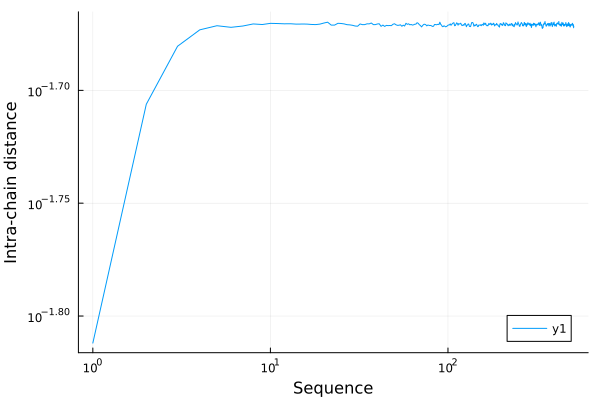

In [52]:
#Plot polymer intra-chain statistics
giration = calcgir(data_r, N, 500,800,1);
Plots.plot(giration[2:N÷2],xaxis=:log10,yaxis=:log10)
# Plots.plot!(0.01*(1:1:N).^(6/5))
xlabel!("Sequence")
ylabel!("Intra-chain distance")

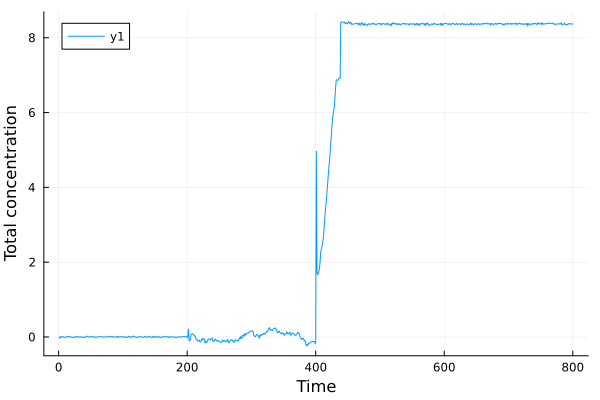

In [50]:
#Plot average epigenetic field dynamics
plot_totprof(data_m,8000)

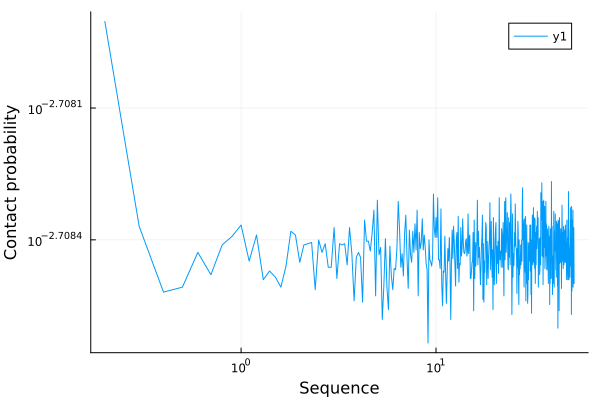

In [41]:
#Plot contact probability

#Calculate contact probability
ps = pofs(data_r,N,0.25,500,1);
#Plot
plot((ds:ds:N÷2*ds)[findall(x->x>0,ps)][2:end],ps[findall(x->x>0,ps)][2:end],xaxis=:log10,yaxis=:log10)
# plot!((ds:ds:N÷2*ds)[2:end], (ds:ds:N÷2*ds)[2:end].^(-1.0), linestyle=:dash)
xlabel!("Sequence")
ylabel!("Contact probability")

[52.149071707498166, 52.12936230937455, 52.1148574217214, 52.10523818036091, 52.09896169208277, 52.09491514230509, 52.092217501009955, 52.09049432522068, 52.08944490008095, 52.08879874495831, 52.08850526446513, 52.088288791163464, 52.08805450747379, 52.0879957170909, 52.08801585464209, 52.08806884353749, 52.08805260254211, 52.08800581081492, 52.08796485684207, 52.08804283893562, 52.08805500434992, 52.08797413289341, 52.08783507350557, 52.08767157221172, 52.087519999850755, 52.08730405365186, 52.08727368371296, 52.087170252549775, 52.08714769369419, 52.08713275707005, 52.08715127502308, 52.08721849456089, 52.0871987897691, 52.08715606784147, 52.08708979552609, 52.087176501919004, 52.08726437899233, 52.08731384878719, 52.0871996532937, 52.087207920901676, 52.087155140429324, 52.08716431736819, 52.08713095676105, 52.08710159248998, 52.087020225331855, 52.08690729801502, 52.08685475025992, 52.08684223882661, 52.086840140790066, 52.08675693091066, 52.08671198896116, 52.0867125720051, 52.086

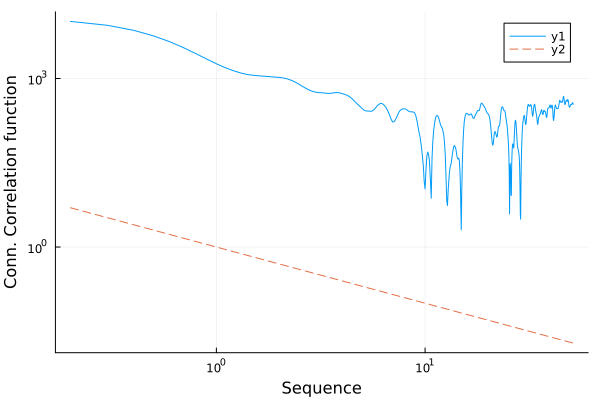

In [429]:
#Plot correlation function

#Calculate correlation function
corrh, conncorrh, avg, avg_spatial = calccorrh(data_m, Nt, 500, 1);
#Plot
plot((ds:ds:N÷2*ds)[2:N÷2],abs.(conncorrh)[2:N÷2],xaxis=:log10,yaxis=:log10)
plot!((ds:ds:N÷2*ds)[2:end], (ds:ds:N÷2*ds)[2:end].^(-1), linestyle=:dash)
xlabel!("Sequence")
ylabel!("Conn. Correlation function")

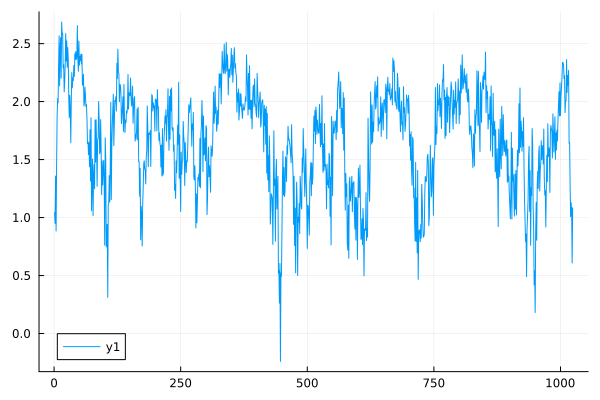

In [13]:
plot(data_m[400,:])